<a href="https://colab.research.google.com/github/postnicov/ResazurinResorufin/blob/main/KubelkaMunk_ColorAnalysis_v4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kubelka–Munk Spectral Reflectance and Color Analysis

**Version 4.2 — wavelength-dependent scattering; RGB output in 0–255 form**

This Colab-ready notebook reads a normalized absorbance spectrum from a user-specified CSV URL, applies Savitzky–Golay smoothing, calculates simplified Kubelka–Munk reflectance with `S(lambda)=S0 exp[-s(lambda-360)]`, and fits positive parameters `S0` and `s` under two criteria: full CIE Lab distance and `(a*,b*)`-plane distance. The absorbance-preprocessing figure displays both the raw and smoothed curves; the downstream reflectance figures use smoothed absorbance only. RGB results are reported as integer sRGB channels in the range 0–255.


In [1]:
#@title Install and Import Required Packages
import importlib
import subprocess
import sys

required = {"numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib", "scipy": "scipy", "colour-science": "colour"}
for pip_name, import_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f"{pip_name} already installed.")
    except ImportError:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import minimize
import colour
from colour import SpectralDistribution, MSDS_CMFS, SDS_ILLUMINANTS
from colour import XYZ_to_Lab, XYZ_to_sRGB, Lab_to_XYZ
print("colour-science version:", colour.__version__)


numpy already installed.
pandas already installed.
matplotlib already installed.
scipy already installed.
Installing colour-science ...
colour-science version: 0.4.7


In [2]:
#@title Set Target CIE L*a*b* Parameters and Spectral Reference URL
target_L_star = 90.2 #@param {type:"number"}
target_a_star = 1.3 #@param {type:"number"}
target_b_star = -10.7 #@param {type:"number"}
spectral_reference_url = "https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/Rz7Ref.csv" #@param {type:"string"}

target_Lab = np.array([target_L_star, target_a_star, target_b_star], dtype=float)
print(f"Target Lab: L*={target_Lab[0]:.4f}, a*={target_Lab[1]:.4f}, b*={target_Lab[2]:.4f}")
print("Spectral reference URL:", spectral_reference_url)


Target Lab: L*=90.2000, a*=1.3000, b*=-10.7000
Spectral reference URL: https://raw.githubusercontent.com/postnicov/ResazurinResorufin/refs/heads/main/Data/Rz7Ref.csv


In [3]:
#@title Set Savitzky-Golay Smoothing and Plot Parameters
savgol_window_length = 15 #@param {type:"integer"}
savgol_polynomial_order = 3 #@param {type:"integer"}
plot_font_size = 12 #@param {type:"integer"}
plot_font_family = "serif" #@param ["serif", "sans-serif", "monospace"]
plot_line_width = 1.5 #@param {type:"number"}

if savgol_window_length < 3 or savgol_window_length % 2 == 0:
    raise ValueError("savgol_window_length must be odd and at least 3.")
if savgol_polynomial_order < 0 or savgol_polynomial_order >= savgol_window_length:
    raise ValueError("savgol_polynomial_order must be non-negative and smaller than savgol_window_length.")

plt.rcParams.update({"font.size": plot_font_size, "font.family": plot_font_family, "lines.linewidth": plot_line_width, "axes.labelsize": plot_font_size, "axes.titlesize": plot_font_size, "legend.fontsize": plot_font_size, "xtick.labelsize": plot_font_size, "ytick.labelsize": plot_font_size})
print(f"Savitzky-Golay: window={savgol_window_length}, polynomial order={savgol_polynomial_order}")


Savitzky-Golay: window=15, polynomial order=3


Loaded 441 points: 360–800 nm


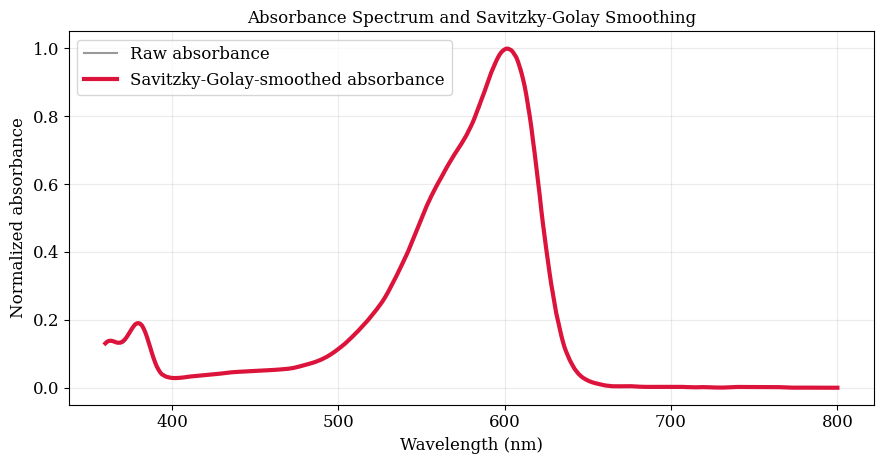

In [4]:
#@title Load and Smooth the Absorbance Spectrum
df = pd.read_csv(spectral_reference_url).dropna().sort_values("lambda").reset_index(drop=True)
if not {"lambda", "Absorbance"}.issubset(df.columns):
    raise ValueError("The CSV file must contain columns named 'lambda' and 'Absorbance'.")
wavelengths = df["lambda"].to_numpy(dtype=float)
absorbance_raw = df["Absorbance"].to_numpy(dtype=float)
if savgol_window_length > len(absorbance_raw):
    raise ValueError("savgol_window_length cannot exceed the number of spectrum points.")

absorbance_smooth = savgol_filter(absorbance_raw, window_length=savgol_window_length, polyorder=savgol_polynomial_order, mode="interp")
absorbance_smooth = np.clip(absorbance_smooth, 0.0, None)
print(f"Loaded {len(wavelengths)} points: {wavelengths.min():.0f}–{wavelengths.max():.0f} nm")

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, absorbance_raw, color="0.60", lw=plot_line_width, label="Raw absorbance")
ax.plot(wavelengths, absorbance_smooth, color="crimson", lw=2 * plot_line_width, label="Savitzky-Golay-smoothed absorbance")
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized absorbance", title="Absorbance Spectrum and Savitzky-Golay Smoothing")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [5]:
#@title Define Kubelka-Munk and Colorimetric Functions
# Wavelength-dependent scattering: S(lambda) = S0 exp[-s(lambda - 360)].
def scattering_coefficient(wavelengths, S0, s):
    return S0 * np.exp(-s * (np.asarray(wavelengths, dtype=float) - 360.0))

def kubelka_munk_reflectance(A, wavelengths, S0, s):
    if S0 <= 0 or s <= 0:
        raise ValueError("S0 and s must both be positive.")
    S_lambda = scattering_coefficient(wavelengths, S0, s)
    x = np.clip(np.asarray(A, dtype=float), 0.0, None) / np.maximum(S_lambda, np.finfo(float).tiny)
    # Stable equivalent of R = 1+x-sqrt(x^2+2x).
    R = 1.0 / (1.0 + x + np.sqrt(x * x + 2.0 * x))
    return np.clip(R, 0.0, 1.0)

cmfs = MSDS_CMFS["CIE 1931 2 Degree Standard Observer"]
illuminant_D65 = SDS_ILLUMINANTS["D65"]
D65_xy = colour.CCS_ILLUMINANTS["CIE 1931 2 Degree Standard Observer"]["D65"]

def reflectance_to_XYZ(reflectance):
    sd = SpectralDistribution(dict(zip(wavelengths, reflectance)), name="Reflectance")
    return colour.sd_to_XYZ(sd.align(cmfs.shape), cmfs=cmfs, illuminant=illuminant_D65)

def XYZ_to_Lab_D65(XYZ):
    return XYZ_to_Lab(XYZ / 100.0, illuminant=D65_xy)

def XYZ_to_RGB_D65(XYZ):
    """Return display-encoded sRGB as integer values in the interval 0–255."""
    RGB_01 = np.clip(XYZ_to_sRGB(XYZ / 100.0, illuminant=D65_xy), 0.0, 1.0)
    return np.rint(RGB_01 * 255.0).astype(int)

def evaluate_parameters(params):
    S0, s = params
    R = kubelka_munk_reflectance(absorbance_smooth, wavelengths, S0, s)
    XYZ = reflectance_to_XYZ(R)
    Lab = XYZ_to_Lab_D65(XYZ)
    RGB = XYZ_to_RGB_D65(XYZ)
    return R, XYZ, Lab, RGB


In [6]:
#@title Optimize Positive S0 and s: Full L*a*b* Distance
bounds = [(1e-8, 100.0), (1e-10, 0.10)]
x0 = np.array([0.5, 0.001])

def full_Lab_error(params):
    try:
        _, _, Lab, _ = evaluate_parameters(params)
        return np.sum((Lab - target_Lab) ** 2)
    except Exception:
        return 1e100

full_fit = minimize(full_Lab_error, x0, method="L-BFGS-B", bounds=bounds, options={"ftol": 1e-14, "gtol": 1e-12, "maxiter": 5000})
S0_full, s_full = full_fit.x
R_full, XYZ_full, Lab_full, RGB_full = evaluate_parameters(full_fit.x)
dE_full = np.sqrt(full_fit.fun)

print("Full L*a*b* optimization")
print(f"  Optimized S0 = {S0_full:.8f}")
print(f"  Optimized s  = {s_full:.8f} nm^-1")
print(f"  Achieved Lab = ({Lab_full[0]:.4f}, {Lab_full[1]:.4f}, {Lab_full[2]:.4f})")
print(f"  Achieved RGB (0–255) = ({RGB_full[0]}, {RGB_full[1]}, {RGB_full[2]})")
print(f"  dE = {dE_full:.4f}")


Full L*a*b* optimization
  Optimized S0 = 11.88262888
  Optimized s  = 0.00000000 nm^-1
  Achieved Lab = (90.1264, 1.0546, -10.6693)
  Achieved RGB (0–255) = (219, 227, 247)
  dE = 0.2581


In [7]:
#@title Optimize Positive S0 and s: (a*, b*) Plane Only
def ab_plane_error(params):
    try:
        _, _, Lab, _ = evaluate_parameters(params)
        return np.sum((Lab[1:] - target_Lab[1:]) ** 2)
    except Exception:
        return 1e100

ab_fit = minimize(ab_plane_error, x0, method="L-BFGS-B", bounds=bounds, options={"ftol": 1e-14, "gtol": 1e-12, "maxiter": 5000})
S0_ab, s_ab = ab_fit.x
R_ab, XYZ_ab, Lab_ab, RGB_ab = evaluate_parameters(ab_fit.x)
dE_ab = np.sqrt(ab_fit.fun)
dE_ab_full_Lab = np.linalg.norm(Lab_ab - target_Lab)

print("(a*, b*)-plane-only optimization")
print(f"  Optimized S0 = {S0_ab:.8f}")
print(f"  Optimized s  = {s_ab:.8f} nm^-1")
print(f"  Achieved Lab = ({Lab_ab[0]:.4f}, {Lab_ab[1]:.4f}, {Lab_ab[2]:.4f})")
print(f"  Achieved RGB (0–255) = ({RGB_ab[0]}, {RGB_ab[1]}, {RGB_ab[2]})")
print(f"  dE_ab = {dE_ab:.4f}")
print(f"  Full-Lab dE for this fit = {dE_ab_full_Lab:.4f}")


(a*, b*)-plane-only optimization
  Optimized S0 = 11.71537925
  Optimized s  = 0.00000000 nm^-1
  Achieved Lab = (90.0609, 1.0657, -10.7380)
  Achieved RGB (0–255) = (218, 227, 247)
  dE_ab = 0.2374
  Full-Lab dE for this fit = 0.2751


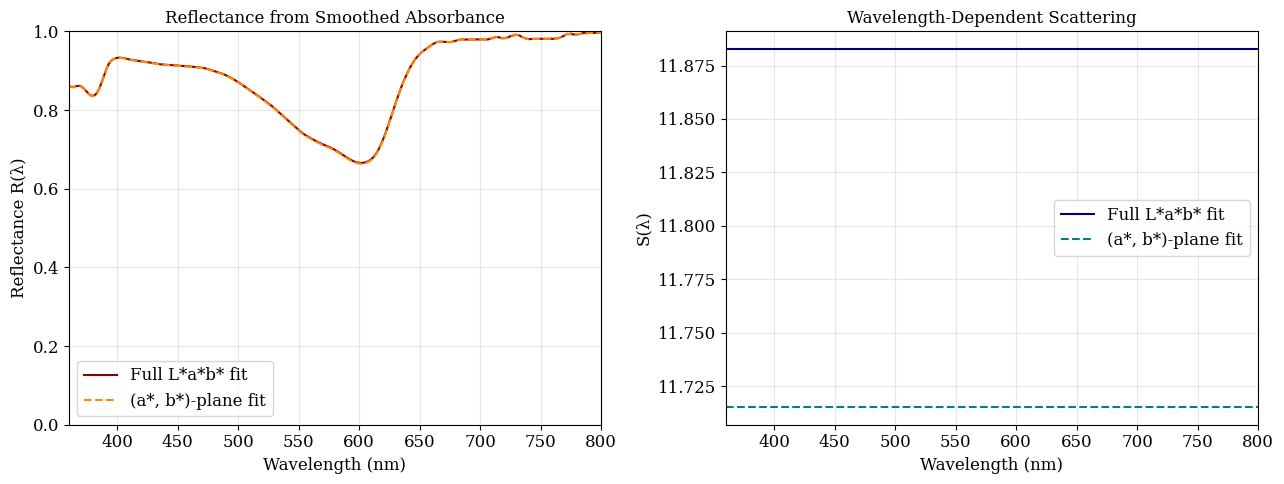

In [8]:
#@title Plot Smoothed Reflectance Spectra and Scattering Functions
S_full = scattering_coefficient(wavelengths, S0_full, s_full)
S_ab = scattering_coefficient(wavelengths, S0_ab, s_ab)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(wavelengths, R_full, color="darkred", label="Full L*a*b* fit")
axes[0].plot(wavelengths, R_ab, color="darkorange", ls="--", label="(a*, b*)-plane fit")
axes[0].set(xlabel="Wavelength (nm)", ylabel="Reflectance R(λ)", title="Reflectance from Smoothed Absorbance", ylim=(0, 1))
axes[0].set_xlim(wavelengths.min(), wavelengths.max())
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(wavelengths, S_full, color="navy", label="Full L*a*b* fit")
axes[1].plot(wavelengths, S_ab, color="teal", ls="--", label="(a*, b*)-plane fit")
axes[1].set(xlabel="Wavelength (nm)", ylabel="S(λ)", title="Wavelength-Dependent Scattering")
axes[1].set_xlim(wavelengths.min(), wavelengths.max())
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()


              Case        S0  s (nm^-1)        L*       a*         b*       dE    dE_ab  R (0-255)  G (0-255)  B (0-255)
  Reference target       NaN        NaN 90.200000 1.300000 -10.700000 0.000000 0.000000        219        227        247
   Full L*a*b* fit 11.882629   0.000000 90.126374 1.054570 -10.669335 0.258064 0.247338        219        227        247
(a*, b*)-plane fit 11.715379   0.000000 90.060909 1.065661 -10.737974 0.275142 0.237396        218        227        247

Final full Lab color distance, dE = 0.2581
Final a*b*-plane color distance, dE_ab = 0.2374


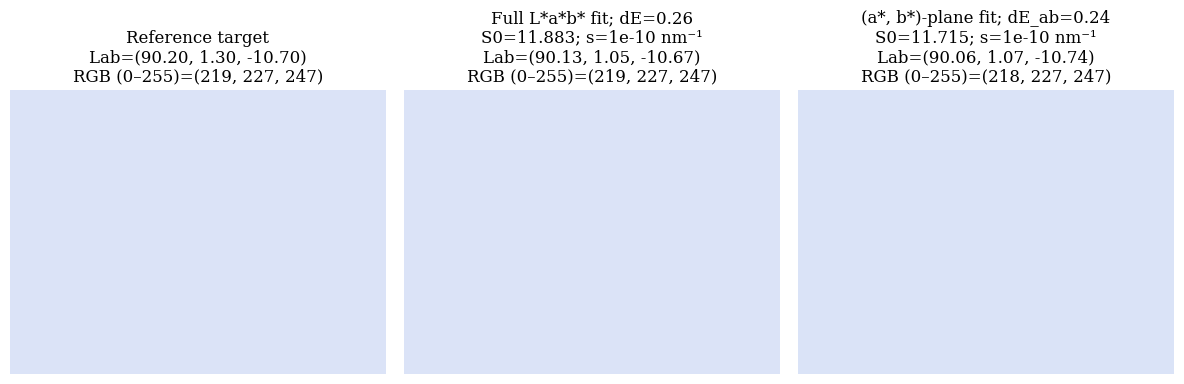

In [9]:
#@title Report Both Fits and Plot Reference / Optimized Color Rectangles
XYZ_reference = Lab_to_XYZ(target_Lab, illuminant=D65_xy) * 100.0
RGB_reference = XYZ_to_RGB_D65(XYZ_reference)

summary = pd.DataFrame({
    "Case": ["Reference target", "Full L*a*b* fit", "(a*, b*)-plane fit"],
    "S0": [np.nan, S0_full, S0_ab],
    "s (nm^-1)": [np.nan, s_full, s_ab],
    "L*": [target_Lab[0], Lab_full[0], Lab_ab[0]],
    "a*": [target_Lab[1], Lab_full[1], Lab_ab[1]],
    "b*": [target_Lab[2], Lab_full[2], Lab_ab[2]],
    "dE": [0.0, dE_full, dE_ab_full_Lab],
    "dE_ab": [0.0, np.linalg.norm(Lab_full[1:] - target_Lab[1:]), dE_ab],
    "R (0-255)": [RGB_reference[0], RGB_full[0], RGB_ab[0]],
    "G (0-255)": [RGB_reference[1], RGB_full[1], RGB_ab[1]],
    "B (0-255)": [RGB_reference[2], RGB_full[2], RGB_ab[2]],
})
print(summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print(f"\nFinal full Lab color distance, dE = {dE_full:.4f}")
print(f"Final a*b*-plane color distance, dE_ab = {dE_ab:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = [RGB_reference / 255.0, RGB_full / 255.0, RGB_ab / 255.0]
titles = [
    f"Reference target\nLab=({target_Lab[0]:.2f}, {target_Lab[1]:.2f}, {target_Lab[2]:.2f})\nRGB (0–255)=({RGB_reference[0]}, {RGB_reference[1]}, {RGB_reference[2]})",
    f"Full L*a*b* fit; dE={dE_full:.2f}\nS0={S0_full:.5g}; s={s_full:.5g} nm⁻¹\nLab=({Lab_full[0]:.2f}, {Lab_full[1]:.2f}, {Lab_full[2]:.2f})\nRGB (0–255)=({RGB_full[0]}, {RGB_full[1]}, {RGB_full[2]})",
    f"(a*, b*)-plane fit; dE_ab={dE_ab:.2f}\nS0={S0_ab:.5g}; s={s_ab:.5g} nm⁻¹\nLab=({Lab_ab[0]:.2f}, {Lab_ab[1]:.2f}, {Lab_ab[2]:.2f})\nRGB (0–255)=({RGB_ab[0]}, {RGB_ab[1]}, {RGB_ab[2]})",
]

for ax, colour_rgb, title in zip(axes, colors, titles):
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=colour_rgb))
    ax.set(xlim=(0, 1), ylim=(0, 1), title=title)
    ax.axis("off")
plt.tight_layout()
plt.show()
